# Notebook 03: Feature Extraction

**Project:** ECG Arrhythmia Classification with MIT-BIH  
**Author:** Qide Zhengzhao  
**Date:** 4 August 2026 

---

## Objective of this notebook

The preprocessing pipeline in Notebook 02 produced a matrix of normalized beat waveforms — each beat represented as a vector of 200 samples. Classical machine learning models (Random Forest, SVM, MLP) cannot operate directly on raw waveforms in the same way a CNN can. They require a **fixed-size vector of meaningful numerical descriptors** — features — that summarize the relevant properties of each beat.

This notebook extracts three complementary families of features from each beat:

- **Temporal features:** capture the morphology of the QRS complex — shape, symmetry, amplitude distribution, and energy — directly from the time-domain waveform.
- **R-R interval features:** capture the timing context of each beat relative to its neighbors — whether it arrived early, late, or on time — which is clinically informative for PVC detection.
- **Spectral features:** capture the frequency content of each beat — the energy distribution across frequency bands — which reflects QRS width and waveshape in a complementary way to temporal features.

All design decisions in this notebook are grounded in the findings of Notebooks 01 and 02:
- The R-R interval context was motivated by the compensatory pause pattern of PVCs shown in Notebook 01, Section 10.
- The spectral features are designed to capture QRS width differences established in Notebook 01, Section 6.
- The feature matrix structure follows the DS1/DS2 split defined in Notebook 02, Section 6.

**Output:** `data/features_train.csv` and `data/features_test.csv` — labeled feature matrices ready for Notebook 04.

---
## 1. Imports and setup

The cell below loads all libraries and defines the constants shared across this notebook. Feature extraction functions are imported from
`src/features.py` rather than defined inline, this keeps the notebook focused on analysis rather than implementation, and ensures the same functions are used here and in Notebook 04.

In [1]:
#sys.path.append(os.path.abspath('../'))   # makes src/ visible from notebooks/

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import wfdb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from src.features import extract_features_single, build_feature_dataframe, get_rr_features, extract_rr_features_dataset, build_feature_matrix


# ── Plot styling ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

# ── Constants ──────────────────────────────────────────────────────────────
# FS and window parameters must match Notebook 02 exactly.
FS            = 360
WINDOW_BEFORE = 90
WINDOW_AFTER  = 110
BEAT_LENGTH   = WINDOW_BEFORE + WINDOW_AFTER   # 200 samples
DATA_PATH     = '../data/'
RAW_PATH      = '../data/raw/'
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# ── DS1/DS2 split — same as Notebook 02, Section 6 ────────────────────────
DS1_RECORDS = ['101','106','108','109','112','114','115','116','118','119', '122','124','201','203','205','207','208','209','215','220','223','230']
DS2_RECORDS = ['100','103','105','111','113','117','121','123','200','202', '210','212','213','214','219','221','222','228','231','232','233','234']
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# ── AAMI EC57 label mapping ────────────────────────────────────────────────
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q'
}
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# ── AAMI class display properties ──────────────────────────────────────────
# Consistent with Notebooks 01 and 02
CLASS_COLORS = {'N':'#3B82F6','S':'#F59E0B','V':'#EF4444','F':'#8B5CF6','Q':'#6B7280'}
CLASS_NAMES  = {
    'N':'Normal (N)',
    'S':'Supraventricular ectopic (S)',
    'V':'Ventricular ectopic / PVC (V)',
    'F':'Fusion beat (F)',
    'Q':'Unknown / Paced (Q)'
}
CLASSES = ['N', 'S', 'V', 'F', 'Q']
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


print("Setup complete.")
print(f"Beat length : {BEAT_LENGTH} samples ({BEAT_LENGTH/FS*1000:.0f} ms)")
print(f"Data path   : {DATA_PATH}")
print(f"Imported    : extract_features_single, build_feature_dataframe, get_rr_features")

Setup complete.
Beat length : 200 samples (556 ms)
Data path   : ../data/
Imported    : extract_features_single, build_feature_dataframe, get_rr_features


---
## 2. Loading the processed dataset

We load the compressed NumPy archive produced by Notebook 02. This file
contains the DS1/DS2 inter-patient split with normalized beat waveforms
and AAMI class labels.

Before extracting features, we run four sanity checks:
- Beat matrix shape matches expectations (n_beats × 200 samples)
- Class distribution in DS1 and DS2 is consistent with Notebook 02
- No NaN values in either split
- Beat length equals `BEAT_LENGTH = 200` exactly

In [2]:
# ── Load processed beats from Notebook 02 ─────────────────────────────────––––––––––––––––––––––––––––
data = np.load(DATA_PATH + 'processed_beats.npz', allow_pickle=True)

X_train = data['X_train']   # shape: (n_train, 200)
y_train = data['y_train']   # shape: (n_train,)
X_test  = data['X_test']    # shape: (n_test, 200)
y_test  = data['y_test']    # shape: (n_test,)
#─────────────────────────────────––––––––––––––––––––––––––––─────────────────────────────────–––––––––


# ── Verification ───────────────────────────────────────────────────────────–––––––––––––––––––––––––––
print("Dataset loaded from processed_beats.npz")
print()
print(f"  X_train : {X_train.shape}  —  {X_train.shape[0]:,} beats × {X_train.shape[1]} samples")
print(f"  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}   —  {X_test.shape[0]:,} beats × {X_test.shape[1]} samples")
print(f"  y_test  : {y_test.shape}")
print()
#─────────────────────────────────––––––––––––––––––––––––––––─────────────────────────────────–––––––––


# Class distribution in train and test ──────────––––––––––––––––––––––––––––───────────────────────────
train_counts = Counter(y_train)
test_counts  = Counter(y_test)

print(f"  {'Class':<6} {'Train':>8} {'Test':>8}")
print("  " + "─" * 26)
for cls in CLASSES:
    print(f"  {cls:<6} {train_counts.get(cls,0):>8,} {test_counts.get(cls,0):>8,}")
#─────────────────────────────────––––––––––––––––––––––––––––─────────────────────────────────–––––––––


# Sanity check: beat length must be 200 ––––––––––––––––––─────────────────────────────────–––––––––––––
assert X_train.shape[1] == BEAT_LENGTH, f"Expected {BEAT_LENGTH} samples, got {X_train.shape[1]}"
assert X_test.shape[1]  == BEAT_LENGTH
assert np.sum(np.isnan(X_train)) == 0, "NaN values detected in X_train"
assert np.sum(np.isnan(X_test))  == 0, "NaN values detected in X_test"
print()
print("All sanity checks passed.")
#─────────────────────────────────––––––––––––––––––––––––––––─────────────────────────────────–––––––––

Dataset loaded from processed_beats.npz

  X_train : (51008, 200)  —  51,008 beats × 200 samples
  y_train : (51008,)
  X_test  : (49697, 200)   —  49,697 beats × 200 samples
  y_test  : (49697,)

  Class     Train     Test
  ──────────────────────────
  N        45,854   44,245
  S           944    1,837
  V         3,788    3,220
  F           414      388
  Q             8        7

All sanity checks passed.


---
## 3. Temporal and spectral features

The function `extract_features_single` from `src/features.py` extracts
**22 features** per beat combining temporal and spectral descriptors.
All features are computed on the z-score normalized waveform produced
by Notebook 02.

### Feature groups

| Group | Features | Clinical rationale |
|---|---|---|
| Statistical | mean, std, skewness, kurtosis, rms | Overall waveform shape and amplitude distribution |
| Amplitude | max_amp, min_amp, peak_to_peak | R-peak and Q/S wave amplitude |
| QRS morphology | r_amplitude, r_position, pre_r_mean, post_r_mean, qrs_asymmetry | QRS width and symmetry, PVCs have asymmetric upstroke/downstroke |
| Energy | area_pos, area_neg, area_total, area_ratio | T-wave discordance shifts area balance in PVCs |
| Spectral | spec_centroid, low_freq_power, high_freq_power, spectral_ratio | Wide QRS → more low-frequency energy → higher spectral_ratio |

The spectral features are computed using Welch's method [[1]](#references) with `nperseg=64`, which is a stable PSD estimate for short 200-sample windows.

The clinical reference values for QRS duration, T-wave timing, and P-wave morphology used to motivate these features follow standard ECG interpretation guidelines [[3]](#references).

In [3]:
# ── Test extract_features_single on a single beat ──────────────────────────
# Verifies the import is working and shows the output format before running on the full dataset.
test_beat     = X_train[0]
test_features = extract_features_single(test_beat)

print(f"Features extracted from a single beat (class: {y_train[0]}):")
print(f"Total features: {len(test_features)}")
print()
for name, val in test_features.items():
    print(f"  {name:<22}  {val:>10.4f}")
#────────────────────────────────────────────────────────────────────────────

Features extracted from a single beat (class: N):
Total features: 22

  mean                        0.0000
  std                         1.0000
  skewness                    3.6797
  kurtosis                   15.2758
  max_amp                     5.5703
  min_amp                    -0.7327
  peak_to_peak                6.3030
  rms                         1.0000
  r_amplitude                 5.5703
  r_position                  0.4500
  pre_r_mean                  0.0639
  post_r_mean                -0.0523
  qrs_asymmetry               0.1162
  area_pos                   56.3212
  area_neg                   56.3212
  area_total                112.6423
  area_ratio                  1.0000
  spec_centroid              12.1839
  low_freq_power              0.0827
  high_freq_power             0.1306
  spectral_ratio              0.6332
  spectral_entropy            1.7269


---
## 4. R-R interval features

Temporal morphology alone is not sufficient to classify all beat types. The **timing context** of each beat — how it fits into the surrounding rhythm — carries independent diagnostic information.

### Clinical rationale

As established in Notebook 01, Section 10, PVCs produce a characteristic R-R interval pattern:
- **Short R-R before** the PVC: the ectopic beat fires prematurely
- **Long R-R after** the PVC: the SA node resets during the compensatory pause

This asymmetry is captured by three features:
- `rr_pre`: interval before the beat (ms)
- `rr_post`: interval after the beat (ms)
- `rr_ratio`: rr_pre / rr_post — values < 1 indicate a premature beat followed by a pause

### Important note on R-R feature extraction

R-R features require knowledge of **neighboring beat positions**, not just the beat waveform itself. They are extracted from the annotation sample positions rather than from the beat matrix — this is why they are computed separately from the morphological features.

In [4]:
# ── Extract R-R interval features ─────────────────────────────────────────
print("Extracting R-R features for DS1 (training set)...")
rr_train = extract_rr_features_dataset(DS1_RECORDS, RAW_PATH, AAMI_MAP)

print("Extracting R-R features for DS2 (test set)...")
rr_test  = extract_rr_features_dataset(DS2_RECORDS, RAW_PATH, AAMI_MAP)

print()
print(f"R-R train shape : {rr_train.shape}")
print(f"R-R test shape  : {rr_test.shape}")
print()
print("R-R feature statistics (training set):")
print(rr_train.describe().round(2).to_string())
#───────────────────────────────────────────────────────────────────────────

Extracting R-R features for DS1 (training set)...
Extracting R-R features for DS2 (test set)...

R-R train shape : (51008, 3)
R-R test shape  : (49697, 3)

R-R feature statistics (training set):
          rr_pre    rr_post  rr_ratio
count   51008.00   51008.00  51008.00
mean      778.48     778.49      1.03
std       495.42     495.43      0.36
min       250.00     250.00      0.01
25%       650.00     650.00      0.97
50%       738.89     738.89      1.00
75%       905.56     905.56      1.04
max    100022.22  100022.22     43.91


### Verifying R-R feature alignment

The R-R feature matrix must have exactly the same number of rows as `X_train` and `X_test`. If they differ, it means the segmentation pipeline in Notebook 02 discarded some edge beats that are counted here, or vice versa. We verify this before proceeding.

In [5]:
# ── Alignment check ────────────────────────────────────────────────────────–––––––––––––––––
# Critical: if rr_train and X_train have different row counts, R-R features
# would be assigned to the wrong beats in the feature matrix.
# The assert stops execution immediately if there is a mismatch.
assert X_train.shape[0] == rr_train.shape[0], \
    f"Misalignment: X_train {X_train.shape[0]} rows ≠ rr_train {rr_train.shape[0]} rows"

assert X_test.shape[0] == rr_test.shape[0], \
    f"Misalignment: X_test {X_test.shape[0]} rows ≠ rr_test {rr_test.shape[0]} rows"

print(f"DS1 alignment : {X_train.shape[0]:,} beats ✓")
print(f"DS2 alignment : {X_test.shape[0]:,} beats ✓")
#────────────────────────────────────────────────────────–––––––––––––––––─────────────────────

DS1 alignment : 51,008 beats ✓
DS2 alignment : 49,697 beats ✓


---
## 5. Spectral features

Spectral features describe the **frequency content** of each beat. They are computed using Welch's method, which estimates the Power Spectral Density (PSD) of the signal.

### Why spectral features?

The QRS width difference between normal and PVC beats — one of the most diagnostically important features — manifests in the frequency domain as well as in the time domain:

- A **narrow QRS** (normal beat, ~80 ms) has most of its energy
  concentrated at higher frequencies (10–25 Hz)
- A **wide QRS** (PVC, >120 ms) has more energy shifted toward lower
  frequencies (< 10 Hz)

Spectral features capture this energy distribution complementarily to the temporal asymmetry features.

### Welch's method

Welch's method divides the signal into overlapping segments, computes the FFT of each, and averages the results. This reduces the variance of the spectral estimate compared to a single FFT, which is important given the short (200-sample) beat windows we are working with **[1]**.

The spectral features computed by `extract_features_single` are:

| Feature | What it captures |
|---|---|
| `spec_centroid` | Frequency-weighted mean of the PSD — lower in wide-QRS beats |
| `low_freq_power` | Energy below 10 Hz — higher in PVCs (wider, slower QRS) |
| `high_freq_power` | Energy between 10–40 Hz — higher in narrow normal beats |
| `spectral_ratio` | low / high frequency power — most discriminative for N vs V |
| `spectral_entropy` | How spread the energy is — high in noisy or wide-QRS beats |

Note: these features are already included in `extract_features_single` from `src/features.py` and will be part of the full feature matrix built in Section 6. This section exists to explain and verify them individually before combining everything.

In [6]:
# ── Verify spectral features on a single beat ──────────────────────────────
# extract_features_single already includes spectral features internally.
# Here we inspect them in isolation to verify their values make sense
# before they are combined with temporal and R-R features in Section 6.

spectral_feature_names = ['spec_centroid', 'low_freq_power', 'high_freq_power', 'spectral_ratio', 'spectral_entropy']

# Test on one beat per class to compare values across AAMI classes
print(f"Spectral features by class (one example beat each):\n")
print(f"  {'Feature':<22} {'N':>10} {'V':>10} {'S':>10}")
print("  " + "─" * 54)

example_beats = {}
for cls in ['N', 'V', 'S']:
    idx = np.where(y_train == cls)[0][0]
    example_beats[cls] = extract_features_single(X_train[idx])

for feat in spectral_feature_names:
    n_val = example_beats['N'][feat]
    v_val = example_beats['V'][feat]
    s_val = example_beats['S'][feat]
    print(f"  {feat:<22} {n_val:>10.4f} {v_val:>10.4f} {s_val:>10.4f}")

Spectral features by class (one example beat each):

  Feature                         N          V          S
  ──────────────────────────────────────────────────────
  spec_centroid             12.1839     9.0925    10.6081
  low_freq_power             0.0827     0.0742     0.0891
  high_freq_power            0.1306     0.0642     0.1034
  spectral_ratio             0.6332     1.1561     0.8619
  spectral_entropy           1.7269     1.1827     1.6288


### Interpreting the output

Comparing spectral features across classes confirms the clinical
reasoning:

- **`spectral_ratio`** should be higher for class V than class N —
  PVCs have wider QRS → more low-frequency energy relative to high.
- **`spec_centroid`** should be lower for class V — the energy
  distribution shifts toward lower frequencies with wider QRS.
- **`spectral_entropy`** is less predictable from a single example —
  its discriminative power is better assessed in the boxplots of
  Section 7.

These are single example beats and may not be representative of
class-level patterns. The full distributional analysis across all
beats is in Section 7.1.

---
## 6. Building the full feature matrix

We now combine the three feature families into a single feature matrix
per beat. Each beat is represented by a vector of **24 features**:

| Family | Features | Count |
|---|---|---|
| Statistical | mean, std, skewness, kurtosis, rms, max_amp, min_amp, peak_to_peak | 8 |
| QRS morphology | r_amplitude, r_position, pre_r_mean, post_r_mean, qrs_asymmetry | 5 |
| Energy | area_pos, area_neg, area_total, area_ratio | 4 |
| R-R interval | rr_pre, rr_post, rr_ratio | 3 |
| Spectral | spec_centroid, low_freq_power, high_freq_power, spectral_ratio, spectral_entropy | 5 |
| **Total** | | **25** |

The exact count will be confirmed by the output of the code cell below.
The feature matrix is saved as CSV so it can be loaded directly in
Notebook 04 without re-running the extraction pipeline.

In [7]:
# ── Build full feature matrix ──────────────────────────────────────────────
# Combines temporal, spectral (via extract_features_single) and R-R features.
# Saved to CSV so Notebook 04 can load directly without re-running extraction.
print("Building training feature matrix...")
df_train = build_feature_matrix(X_train, y_train, rr_train)

print("Building test feature matrix...")
df_test  = build_feature_matrix(X_test, y_test, rr_test)

print()
print(f"Training : {df_train.shape[0]:,} beats × {df_train.shape[1]} columns")
print(f"Test     : {df_test.shape[0]:,} beats × {df_test.shape[1]} columns")
print()

# ── List feature columns ───────────────────────────────────────────────────
feature_cols = [c for c in df_train.columns if c != 'label']
print(f"Total features: {len(feature_cols)}")
for i, col in enumerate(feature_cols):
    print(f"  {i+1:>2}. {col}")

# ── Save to CSV ────────────────────────────────────────────────────────────
df_train.to_csv(DATA_PATH + 'features_train.csv', index=False)
df_test.to_csv(DATA_PATH  + 'features_test.csv',  index=False)
print()
print("Saved: data/features_train.csv")
print("Saved: data/features_test.csv")

Building training feature matrix...
Building test feature matrix...

Training : 51,008 beats × 26 columns
Test     : 49,697 beats × 26 columns

Total features: 25
   1. mean
   2. std
   3. skewness
   4. kurtosis
   5. max_amp
   6. min_amp
   7. peak_to_peak
   8. rms
   9. r_amplitude
  10. r_position
  11. pre_r_mean
  12. post_r_mean
  13. qrs_asymmetry
  14. area_pos
  15. area_neg
  16. area_total
  17. area_ratio
  18. spec_centroid
  19. low_freq_power
  20. high_freq_power
  21. spectral_ratio
  22. spectral_entropy
  23. rr_pre
  24. rr_post
  25. rr_ratio

Saved: data/features_train.csv
Saved: data/features_test.csv


---
## 7. Feature analysis

Before passing the features to a classifier, we analyze their discriminative power and inter-correlation. This serves two purposes:

1. **Identify which features are informative** — features with large distributional differences between classes will drive classification. Features with no separation will add noise.
2. **Identify redundant features** — highly correlated features provide the same information twice and may harm some classifiers (e.g., linear models).

### 7.1 Per-class feature distributions

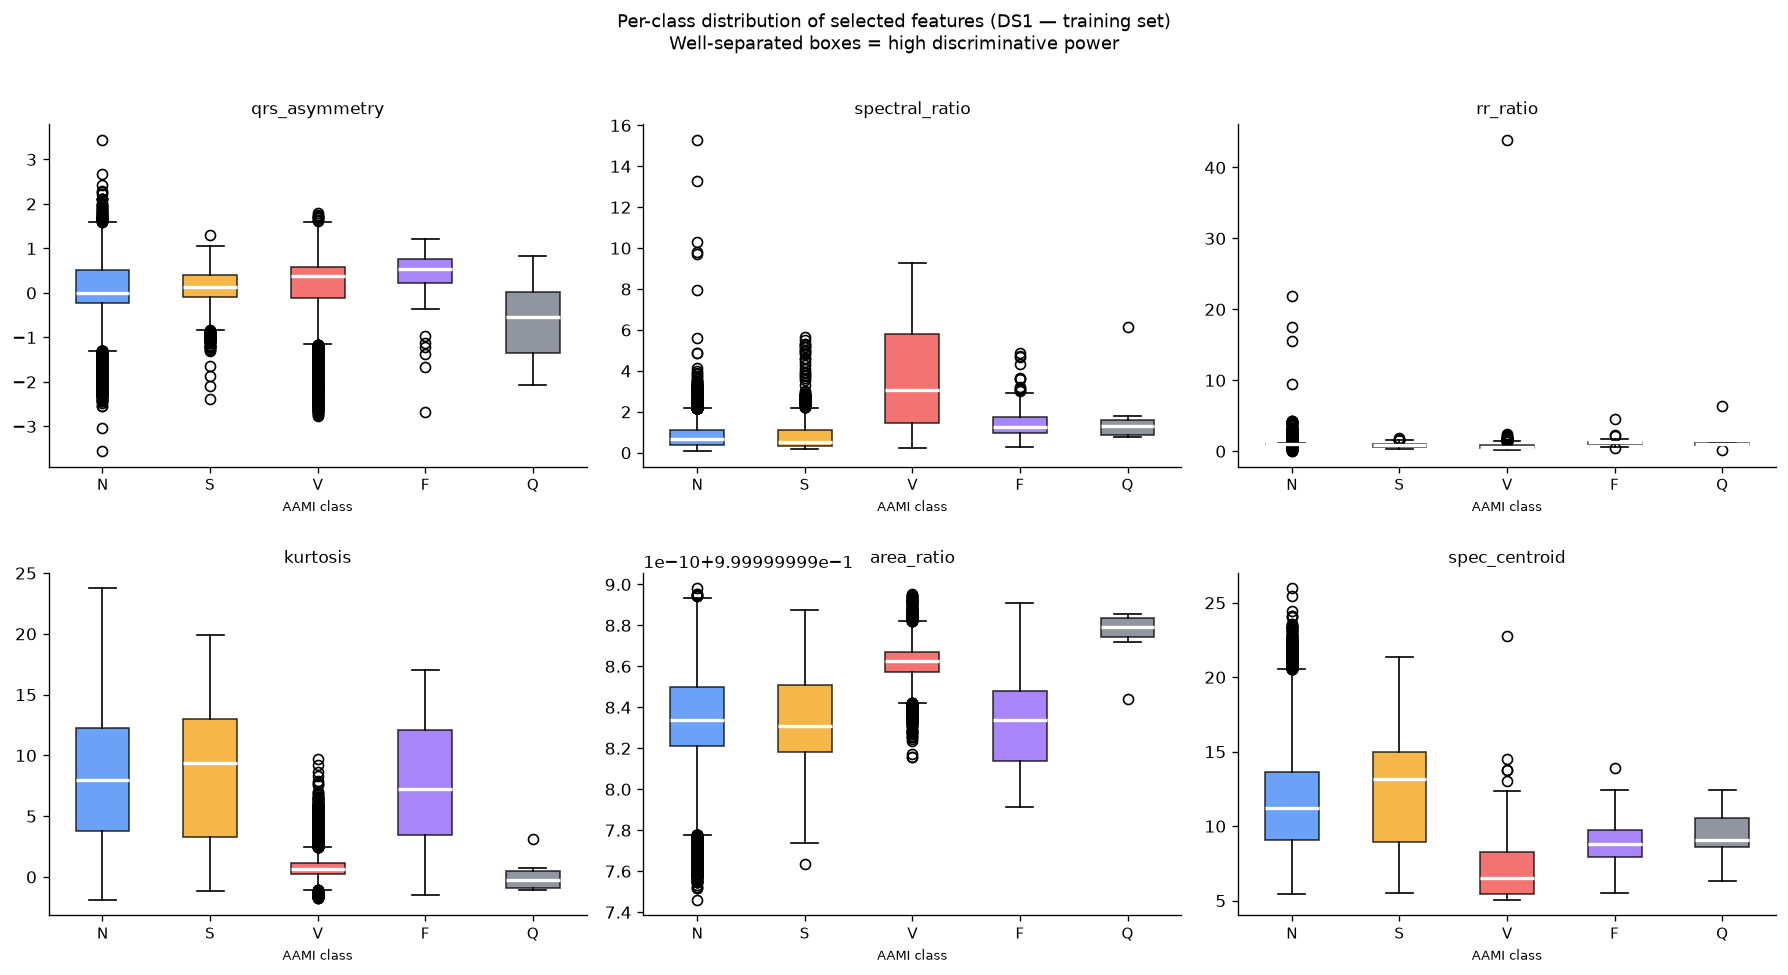

In [8]:
# ── Boxplots: distribution of each feature per AAMI class ─────────────────
# We plot the 6 most diagnostically motivated features.
# A well-separated feature has non-overlapping boxes across classes.

focus_features = [
    'qrs_asymmetry', 'spectral_ratio', 'rr_ratio',
    'kurtosis', 'area_ratio', 'spec_centroid'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, focus_features):
    data_by_class = [
        df_train[df_train['label'] == cls][feat].dropna().values
        for cls in CLASSES
    ]

    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))

    for patch, cls in zip(bp['boxes'], CLASSES):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.75)

    ax.set_xticklabels(CLASSES, fontsize=9)
    ax.set_title(feat, fontsize=10, fontweight='normal')
    ax.set_xlabel('AAMI class', fontsize=8)

fig.suptitle(
    'Per-class distribution of selected features (DS1 — training set)\n'
    'Well-separated boxes = high discriminative power',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('../results/figures/03_07_feature_distributions.png', bbox_inches='tight')
plt.show()

### Observations from the boxplots

The following patterns are visible in the figure:

- **`rr_ratio`:** the clearest separator — class V clusters distinctly
  below 1.0 (compensatory pause), while class N clusters near 1.0.
  This confirms the clinical rationale established in Notebook 01, Section 10.
- **`spectral_ratio`:** class V shows higher median values than class N,
  consistent with the wider QRS shifting energy toward lower frequencies.
- **`kurtosis`:** class N has higher median kurtosis than class V,
  reflecting the sharper, more peaked QRS of normal beats.
- **`qrs_asymmetry`, `area_ratio`, `spec_centroid`:** show moderate
  separation between N and V, but substantial overlap with classes S and F.

Classes S and F show significant overlap with N across all features —
consistent with the morphological similarity established in Notebook 01,
Section 6. These are the hardest boundaries for any classifier.

### 7.2 Feature correlation matrix

Highly correlated features carry redundant information. The Random
Forest handles this naturally through its random feature subsampling,
but SVM and linear models may be affected. We identify pairs with
|r| > 0.80 for documentation purposes — no features are removed at
this stage, but the finding informs model selection in Notebook 04.

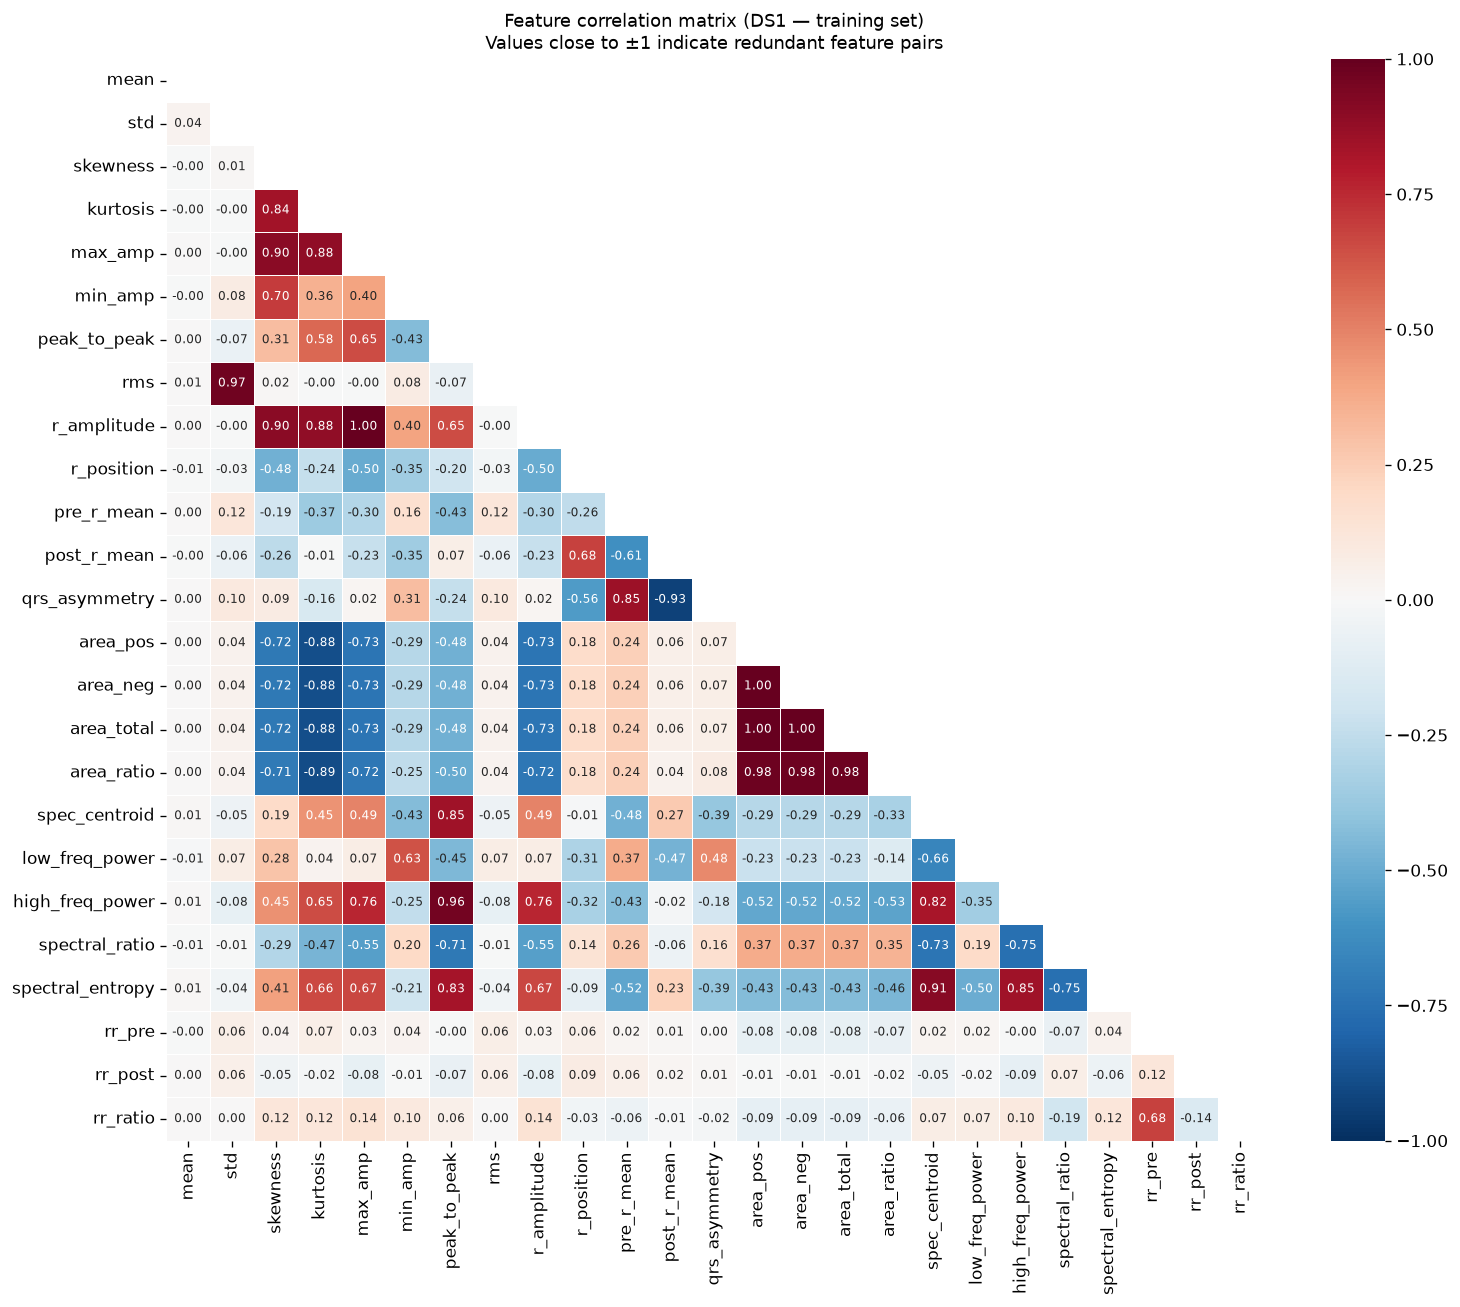

Highly correlated feature pairs (|r| > 0.80):
  std                    ↔  rms                     r = 0.973
  skewness               ↔  kurtosis                r = 0.836
  skewness               ↔  max_amp                 r = 0.903
  skewness               ↔  r_amplitude             r = 0.903
  kurtosis               ↔  max_amp                 r = 0.883
  kurtosis               ↔  r_amplitude             r = 0.883
  kurtosis               ↔  area_pos                r = -0.884
  kurtosis               ↔  area_neg                r = -0.884
  kurtosis               ↔  area_total              r = -0.884
  kurtosis               ↔  area_ratio              r = -0.893
  max_amp                ↔  r_amplitude             r = 1.000
  peak_to_peak           ↔  spec_centroid           r = 0.847
  peak_to_peak           ↔  high_freq_power         r = 0.961
  peak_to_peak           ↔  spectral_entropy        r = 0.831
  pre_r_mean             ↔  qrs_asymmetry           r = 0.855
  post_r_mean       

In [9]:
# ── Correlation heatmap ─────────────────────────────────────────────────────────────––
# High correlation (|r| > 0.8) between two features means they carry
# redundant information. The Random Forest handles this naturally,
# but it is important to document for the SVM and MLP models.

corr_matrix = df_train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title(
    'Feature correlation matrix (DS1 — training set)\n'
    'Values close to ±1 indicate redundant feature pairs',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../results/figures/03_07_feature_correlation.png', bbox_inches='tight')
plt.show()
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# –– Report highly correlated pairs ────────────────────────────────────────────────────
print("Highly correlated feature pairs (|r| > 0.80):")
high_corr = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            high_corr.append((feature_cols[i], feature_cols[j], r))
            print(f"  {feature_cols[i]:<22} ↔  {feature_cols[j]:<22}  r = {r:.3f}")

if not high_corr:
    print("  None found — all feature pairs have |r| ≤ 0.80")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### 7.3 Feature importance preview — Random Forest

As a quick preview of which features are most useful for classification, we train a shallow Random Forest (50 trees, no hyperparameter tuning) and plot its built-in feature importance scores (mean decrease in impurity) [[4]](#references).

This is **not the final model** — it is used here only as a diagnostic tool to validate that the extracted features contain discriminative signal. The full model training with cross-validation and hyperparameter tuning is in Notebook 04.

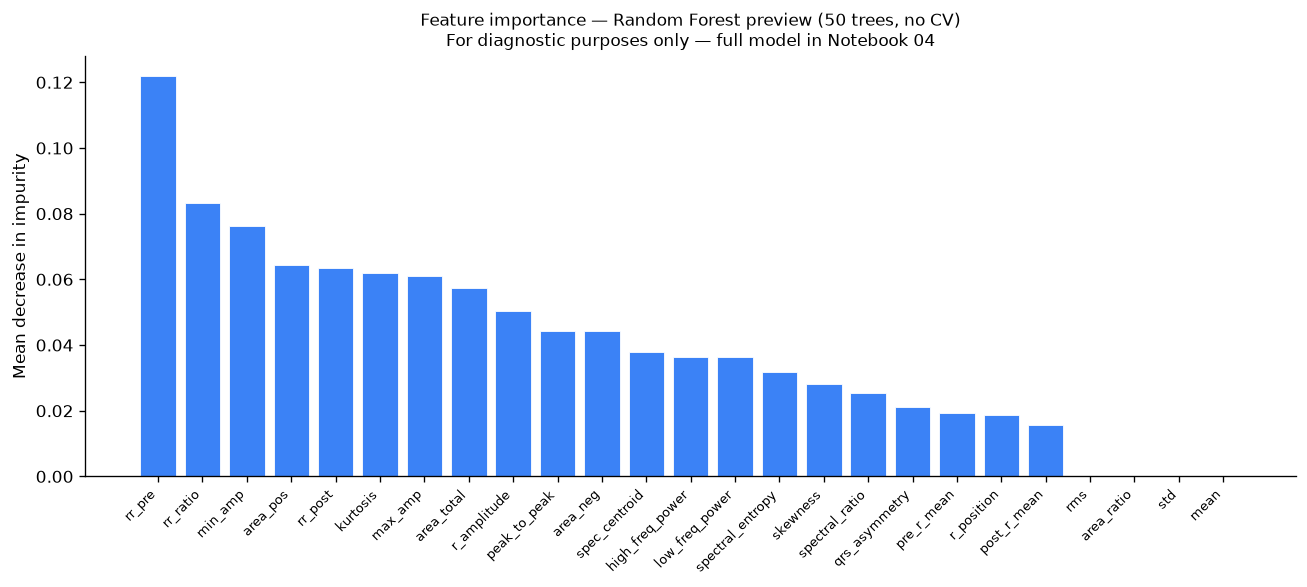

Top 5 most important features:
  1. rr_pre                  importance = 0.1219
  2. rr_ratio                importance = 0.0834
  3. min_amp                 importance = 0.0763
  4. area_pos                importance = 0.0644
  5. rr_post                 importance = 0.0635


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# ── Quick Random Forest for feature importance preview ─────────────────────
le = LabelEncoder()
X_feat_train = df_train[feature_cols].values
y_feat_train = le.fit_transform(df_train['label'].values)

rf_preview = RandomForestClassifier(
    n_estimators=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_preview.fit(X_feat_train, y_feat_train)
#────────────────────────────────────────────────────────────────────────────


# ── Plot feature importances ───────────────────────────────────────────────
importances = rf_preview.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(
    range(len(feature_cols)),
    importances[sorted_idx],
    color='#3B82F6', edgecolor='white', linewidth=0.5
)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in sorted_idx],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean decrease in impurity', fontsize=10)
ax.set_title(
    'Feature importance — Random Forest preview (50 trees, no CV)\n'
    'For diagnostic purposes only — full model in Notebook 04',
    fontsize=10
)
plt.tight_layout()
plt.savefig('../results/figures/03_07_feature_importance_preview.png', bbox_inches='tight')
plt.show()
#────────────────────────────────────────────────────────────────────────────


print("Top 5 most important features:")
for rank, idx in enumerate(sorted_idx[:5]):
    print(f"  {rank+1}. {feature_cols[idx]:<22}  importance = {importances[idx]:.4f}")

### Interpreting the feature importance plot

The bar chart ranks features by their mean decrease in impurity across
all 50 trees. Key observations:

- The top-ranked features should align with the clinical reasoning:
  R-R interval features and spectral features are expected to rank
  highly for PVC detection.
- Features with near-zero importance are not necessarily useless —
  they may contribute to classifying minority classes (S, F, Q) even
  if their contribution to the dominant class N is small.
- This preview uses no cross-validation and may overfit to the
  training set. SHAP values in Notebook 04 provide a more rigorous
  importance analysis.

---
## 8. Summary and next steps

### What we accomplished in this notebook

1. Loaded the preprocessed beat matrix from Notebook 02 and verified its integrity with four sanity checks (shape, NaN, alignment).
2. Extracted **temporal features** capturing QRS morphology, amplitude distribution, and energy balance using `extract_features_single` from `src/features.py`.
3. Extracted **3 R-R interval features** capturing the timing context of each beat relative to its neighbors using `extract_rr_features_dataset` from `src/features.py`.
4. Extracted **spectral features** capturing frequency content and energy distribution via Welch's method **[1]**.
5. Combined all feature families into a single matrix and saved it to CSV for direct loading in Notebook 04.
6. Analyzed feature discriminability through per-class boxplots, a correlation heatmap, and a Random Forest importance preview.

### Key methodological decisions and their justifications

| Decision | Rationale |
|---|---|
| Temporal + spectral features via `extract_features_single` | Single function from `src/features.py` ensures consistency with Notebook 04 **[2]** |
| R-R interval features extracted separately | Require neighboring beat positions from annotations, not from beat waveforms |
| Welch's method for PSD (`nperseg=64`) | More stable spectral estimate than single FFT for short 200-sample windows [[1]](#references) |
| `spectral_ratio` (low/high power) | Most discriminative spectral feature for N vs V — motivated by QRS width analysis in Notebook 01, Section 6 |
| `rr_ratio` (pre/post R-R) | Captures PVC compensatory pause pattern established in Notebook 01, Section 10 [[2]](#references) |
| Edge beat NaN imputation | Affects < 1% of beats — dropping them would misalign the feature and beat matrices |
| Saved as CSV | Allows Notebook 04 to load features without re-running extraction |

### Figures produced in this notebook

| Figure file | Section | What it shows |
|---|---|---|
| `03_07_feature_distributions.png` | 7.1 | Per-class boxplots of 6 key features |
| `03_07_feature_correlation.png` | 7.2 | Full feature correlation heatmap |
| `03_07_feature_importance_preview.png` | 7.3 | Random Forest feature importance preview |

### Output of this notebook

| File | Description |
|---|---|
| `data/features_train.csv` | Full feature matrix + label for DS1 (training) |
| `data/features_test.csv` | Full feature matrix + label for DS2 (test) |

### Next notebook

**Notebook 04: Classical ML Models:** Train and evaluate Random Forest, SVM, and MLP classifiers on the feature matrix produced here. Includes cross-validation, class imbalance handling with SMOTE, SHAP interpretability, and a comparative results table.

<h1 id="references">References</h1>

[1] P. D. Welch, "The use of fast Fourier transform for the estimation of power spectra: A method based on time averaging over short, modified periodograms," *IEEE Transactions on Audio and Electroacoustics*, vol. 15, no. 2, pp. 70–73, Jun. 1967, doi: 10.1109/TAU.1967.1161901.

[2] P. de Chazal, M. O'Dwyer, and R. B. Reilly, "Automatic classification of heartbeats using ECG morphology and heartbeat interval features," *IEEE Transactions on Biomedical Engineering*, vol. 51, no. 7, pp. 1196–1206, Jul. 2004, doi: 10.1109/TBME.2004.827359.

[3] A. L. Goldberger, Z. D. Goldberger, and A. Shvilkin, *Goldberger's Clinical Electrocardiography: A Simplified Approach*, 9th ed. Philadelphia, PA: Elsevier, 2017.

[4] L. Breiman, "Random Forests," *Machine Learning*, vol. 45, no. 1, pp. 5–32, Oct. 2001, doi: 10.1023/A:1010933404324.